# Reward Function Visualisation

Two-stage reward function for the RL environment.

**Stage 1 (always active)**
- `r_vnin` — steepened power-law penalty: `−weight × (VNin/ref)^1.5`
- `r_power` — quadratic Ibias penalty, scaling in with `progress` as VNin improves

**Stage 2 (gated: only active once VNin < vnin_gate_threshold)**
- `r_fc` — `freq_weight × tanh(fchop_margin / fc_scale)`
- `r_area` — linear penalty on area above budget

The gate boundary at `vnin_gate_threshold = 6.0 nV/√Hz` is highlighted throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Hyperparameters (match EnviromentSetup defaults) 
vnin_weight         = 0.8
vnin_reference      = 10.0    # nV/√Hz
vnin_gate_threshold = 6.0     # nV/√Hz  — gate boundary
vnin_target         = 4.5     # nV/√Hz  — terminal success

power_weight        = 0.3
ibias_ref           = 30e-6   # A

freq_weight         = 0.6
fc_scale            = 150e3   # Hz
Fchop               = 51e3    # Hz
signal_bw           = 1000.0  # Hz

area_weight         = 0.8
area_budget_um2     = 500.0   # µm²

terminal_bonus      = 1.0
step_cost           = 0.02

# Component functions 
def r_vnin(VNin_nV):
    return -vnin_weight * (VNin_nV / vnin_reference) ** 1.5

def progress(VNin_nV):
    return np.clip(
        (vnin_reference - VNin_nV) / (vnin_reference - vnin_gate_threshold),
        0.0, 1.0
    )

def r_power(VNin_nV, Ibias):
    p = progress(VNin_nV)
    return -power_weight * (Ibias / ibias_ref) ** 2 * (0.15 + 0.85 * p)

def r_fc_gated(fchop_margin, VNin_nV):
    val = freq_weight * np.tanh(fchop_margin / fc_scale)
    return np.where(VNin_nV < vnin_gate_threshold, val, 0.0)

def r_area_gated(area_um2, VNin_nV):
    excess  = np.maximum(0.0, area_um2 - area_budget_um2)
    penalty = -area_weight * (excess / area_budget_um2)
    return np.where(VNin_nV < vnin_gate_threshold, penalty, 0.0)

def total_reward(VNin_nV, Ibias, fchop_margin, area_um2):
    r = (r_vnin(VNin_nV)
         + r_power(VNin_nV, Ibias)
         + r_fc_gated(fchop_margin, VNin_nV)
         + r_area_gated(area_um2, VNin_nV)
         - step_cost)
    bonus = np.where(
        (VNin_nV < vnin_target) & (fchop_margin > 0.0),
        terminal_bonus, 0.0
    )
    return r + bonus

print('Reward functions defined.')
print(f'Gate boundary:  VNin < {vnin_gate_threshold} nV/√Hz')
print(f'Terminal target: VNin < {vnin_target} nV/√Hz  AND  fchop_margin > 0')

Reward functions defined.
Gate boundary:  VNin < 6.0 nV/√Hz
Terminal target: VNin < 4.5 nV/√Hz  AND  fchop_margin > 0


---
## 1 — Stage 1 Component Lines
r_vnin and r_power vs VNin, at three Ibias levels. Progress scalar shown separately.

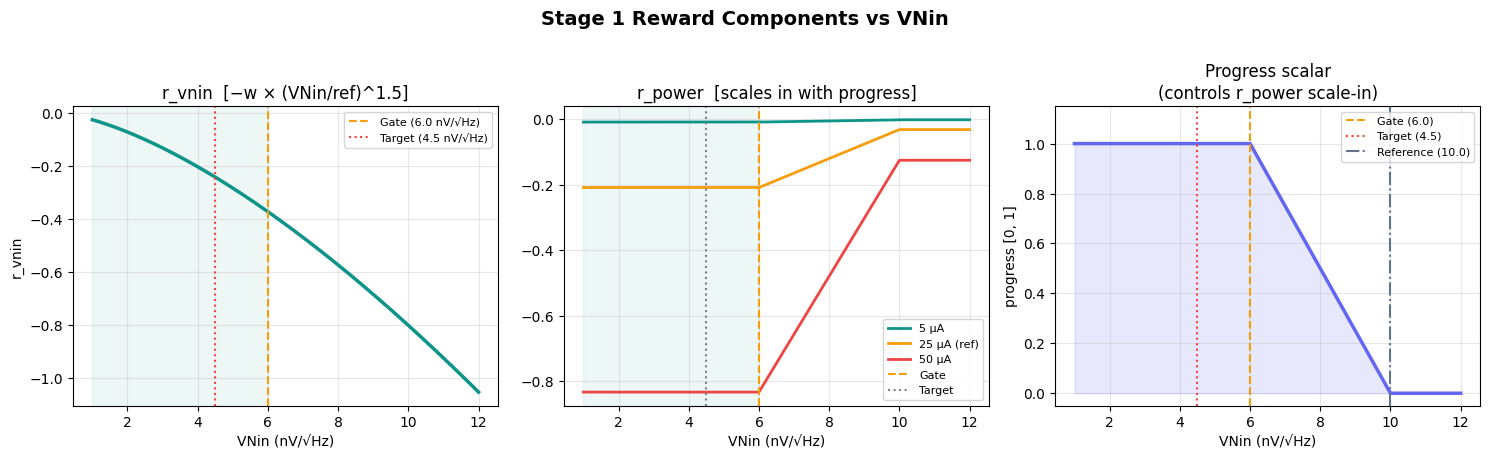

In [2]:
VNin_range     = np.linspace(1.0, 12.0, 500)
ibias_levels   = [5e-6, 25e-6, 50e-6]
ibias_labels   = ['5 µA', '25 µA (ref)', '50 µA']
ibias_colors   = ['#0D9488', '#F59E0B', '#EF4444']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Stage 1 Reward Components vs VNin', fontsize=14, fontweight='bold', y=1.01)

# r_vnin
ax = axes[0]
ax.plot(VNin_range, r_vnin(VNin_range), color='#0D9488', lw=2.5)
ax.axvline(vnin_gate_threshold, color='#F59E0B', ls='--', lw=1.5, label=f'Gate ({vnin_gate_threshold} nV/√Hz)')
ax.axvline(vnin_target,         color='#EF4444', ls=':',  lw=1.5, label=f'Target ({vnin_target} nV/√Hz)')
ax.axvspan(1.0, vnin_gate_threshold, alpha=0.07, color='#0D9488')
ax.set_xlabel('VNin (nV/√Hz)'); ax.set_ylabel('r_vnin')
ax.set_title('r_vnin  [−w × (VNin/ref)^1.5]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# r_power at three Ibias
ax = axes[1]
for ib, label, col in zip(ibias_levels, ibias_labels, ibias_colors):
    ax.plot(VNin_range, r_power(VNin_range, ib), color=col, lw=2.0, label=label)
ax.axvline(vnin_gate_threshold, color='#F59E0B', ls='--', lw=1.5, label='Gate')
ax.axvline(vnin_target,         color='gray',    ls=':',  lw=1.5, label='Target')
ax.axvspan(1.0, vnin_gate_threshold, alpha=0.07, color='#0D9488')
ax.set_xlabel('VNin (nV/√Hz)')
ax.set_title('r_power  [scales in with progress]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# progress scalar
ax = axes[2]
ax.plot(VNin_range, progress(VNin_range), color='#6366F1', lw=2.5)
ax.axvline(vnin_gate_threshold, color='#F59E0B', ls='--', lw=1.5, label=f'Gate ({vnin_gate_threshold})')
ax.axvline(vnin_target,         color='#EF4444', ls=':',  lw=1.5, label=f'Target ({vnin_target})')
ax.axvline(vnin_reference,      color='#64748B', ls='-.', lw=1.5, label=f'Reference ({vnin_reference})')
ax.fill_between(VNin_range, 0, progress(VNin_range), alpha=0.15, color='#6366F1')
ax.set_xlabel('VNin (nV/√Hz)'); ax.set_ylabel('progress [0, 1]')
ax.set_title('Progress scalar\n(controls r_power scale-in)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('reward_stage1_lines.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 — Stage 2 Component Lines: r_fc and r_area
These components only activate once the gate is unlocked.

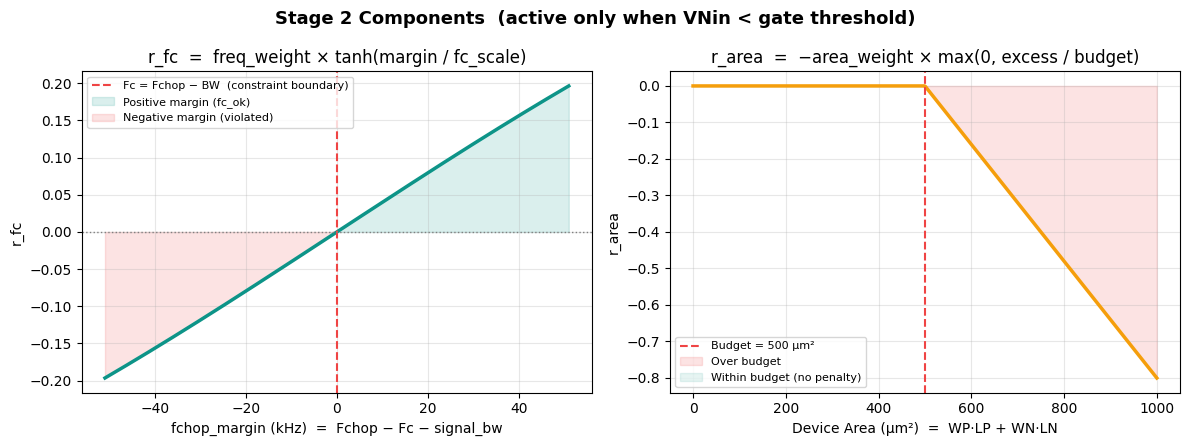

In [3]:
fc_margin_range = np.linspace(-Fchop, Fchop, 500)
area_range      = np.linspace(0, 1000, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Stage 2 Components  (active only when VNin < gate threshold)',
             fontsize=13, fontweight='bold')

# r_fc
ax = axes[0]
fc_vals = freq_weight * np.tanh(fc_margin_range / fc_scale)
ax.plot(fc_margin_range / 1e3, fc_vals, color='#0D9488', lw=2.5)
ax.axvline(0, color='#EF4444', ls='--', lw=1.5, label='Fc = Fchop − BW  (constraint boundary)')
ax.axhline(0, color='gray', ls=':', lw=1.0)
ax.fill_between(fc_margin_range / 1e3, 0, fc_vals, where=fc_margin_range > 0,
                alpha=0.15, color='#0D9488', label='Positive margin (fc_ok)')
ax.fill_between(fc_margin_range / 1e3, 0, fc_vals, where=fc_margin_range < 0,
                alpha=0.15, color='#EF4444', label='Negative margin (violated)')
ax.set_xlabel('fchop_margin (kHz)  =  Fchop − Fc − signal_bw', fontsize=10)
ax.set_ylabel('r_fc'); ax.set_title('r_fc  =  freq_weight × tanh(margin / fc_scale)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.annotate(f'fc_scale = {fc_scale/1e3:.0f} kHz',
            xy=(fc_scale/1e3, freq_weight * np.tanh(1.0)),
            xytext=(fc_scale/1e3 + 12, freq_weight * np.tanh(1.0) - 0.1),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

# r_area
ax = axes[1]
area_penalty = -area_weight * np.maximum(0, area_range - area_budget_um2) / area_budget_um2
ax.plot(area_range, area_penalty, color='#F59E0B', lw=2.5)
ax.axvline(area_budget_um2, color='#EF4444', ls='--', lw=1.5, label=f'Budget = {area_budget_um2:.0f} µm²')
ax.fill_between(area_range, 0, area_penalty, where=area_range > area_budget_um2,
                alpha=0.15, color='#EF4444', label='Over budget')
ax.fill_between(area_range, 0, area_penalty, where=area_range <= area_budget_um2,
                alpha=0.10, color='#0D9488', label='Within budget (no penalty)')
ax.set_xlabel('Device Area (µm²)  =  WP·LP + WN·LN', fontsize=10)
ax.set_ylabel('r_area'); ax.set_title('r_area  =  −area_weight × max(0, excess / budget)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reward_stage2_lines.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 — Stage 2 Heatmap: r_fc + r_area  (fchop_margin × area)


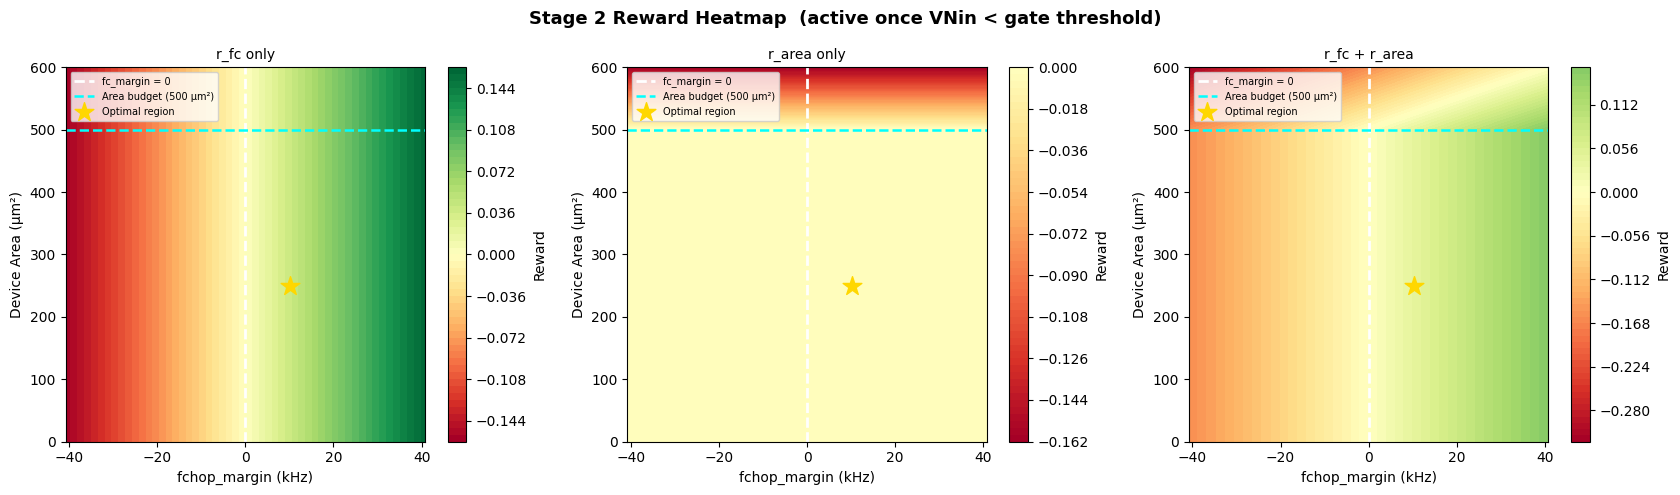

Stage 2 range: [-0.319, 0.159]


In [4]:
fc_g   = np.linspace(-Fchop * 0.8, Fchop * 0.8, 300)
area_g = np.linspace(0, 600, 300)
FM, AA = np.meshgrid(fc_g, area_g)

R_fc2   = freq_weight * np.tanh(FM / fc_scale)
R_area2 = -area_weight * np.maximum(0, AA - area_budget_um2) / area_budget_um2
R_s2    = R_fc2 + R_area2

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Stage 2 Reward Heatmap  (active once VNin < gate threshold)',
             fontsize=13, fontweight='bold')

for ax, (data, title) in zip(axes, [(R_fc2, 'r_fc only'), (R_area2, 'r_area only'), (R_s2, 'r_fc + r_area')]):
    vabs = max(abs(data.min()), abs(data.max()))
    norm = TwoSlopeNorm(vmin=-vabs, vcenter=0.0, vmax=vabs)
    im = ax.contourf(fc_g / 1e3, area_g, data, levels=60, cmap='RdYlGn', norm=norm)
    fig.colorbar(im, ax=ax, label='Reward')
    ax.axvline(0, color='white', ls='--', lw=2.0, label='fc_margin = 0')
    ax.axhline(area_budget_um2, color='cyan', ls='--', lw=1.8, label=f'Area budget ({area_budget_um2:.0f} µm²)')
    ax.scatter([Fchop * 0.2 / 1e3], [area_budget_um2 * 0.5],
               marker='*', s=200, color='gold', zorder=5, label='Optimal region')
    ax.set_xlabel('fchop_margin (kHz)', fontsize=10)
    ax.set_ylabel('Device Area (µm²)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig('reward_stage2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Stage 2 range: [{R_s2.min():.3f}, {R_s2.max():.3f}]')

---
## 5 — Total Reward Heatmap: VNin × Ibias at fixed Stage 2 conditions
Shows how the landscape shifts across three Stage 2 scenarios.

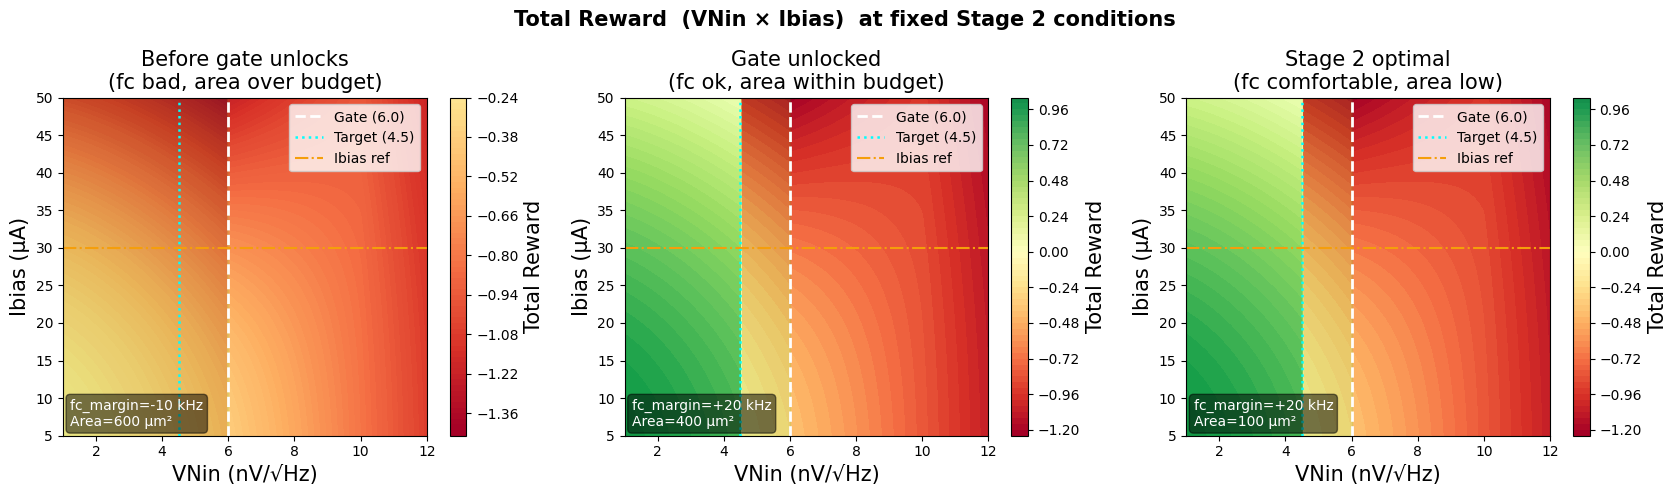

In [5]:
VNin_g  = np.linspace(1.0, 12.0, 300)
Ibias_g = np.linspace(5e-6, 50e-6, 300)
VV, II  = np.meshgrid(VNin_g, Ibias_g)

scenarios = [
    ('Before gate unlocks\n(fc bad, area over budget)',  -10e3, 600.0),
    ('Gate unlocked\n(fc ok, area within budget)',    +20e3,  400.0),
    ('Stage 2 optimal\n(fc comfortable, area low)',     +20e3, 100.0),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Total Reward  (VNin × Ibias)  at fixed Stage 2 conditions',
             fontsize=15, fontweight='bold')

for ax, (title, fc_fixed, area_fixed) in zip(axes, scenarios):
    R_tot = total_reward(VV, II, fc_fixed, area_fixed)
    vabs  = max(abs(R_tot.min()), abs(R_tot.max()))
    norm  = TwoSlopeNorm(vmin=-vabs, vcenter=0.0, vmax=vabs)
    im    = ax.contourf(VNin_g, Ibias_g * 1e6, R_tot, levels=60, cmap='RdYlGn', norm=norm)
    ax.axvline(vnin_gate_threshold, color='white',  ls='--', lw=2.0, label=f'Gate ({vnin_gate_threshold})')
    ax.axvline(vnin_target,         color='cyan',   ls=':',  lw=1.8, label=f'Target ({vnin_target})')
    ax.axhline(ibias_ref * 1e6,     color='#F59E0B',ls='-.',lw=1.5, label='Ibias ref')
    ax.axvspan(1.0, vnin_gate_threshold, alpha=0.08, color='lime')
    ax.set_xlabel('VNin (nV/√Hz)', fontsize=15)
    ax.set_ylabel('Ibias (µA)',    fontsize=15)
    ax.set_title(title, fontsize=15)
    ax.legend(fontsize=10, loc='upper right')
    ax.text(0.02, 0.02, f'fc_margin={fc_fixed/1e3:+.0f} kHz\nArea={area_fixed:.0f} µm²',
            transform=ax.transAxes, fontsize=10, color='white', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.5))
    cb = fig.colorbar(im, ax=ax)
    cb.ax.set_ylabel('Total Reward', fontsize=15)

plt.tight_layout()
plt.savefig('reward_total_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Cross-Section at the Gate Boundary
Total reward vs VNin at Ibias = 25 µA, showing the reward jump when Stage 2 unlocks.

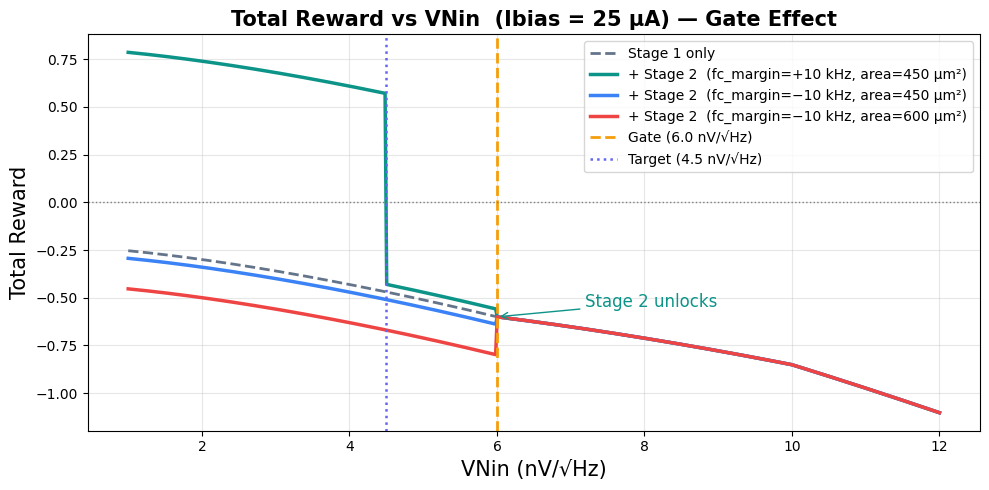

Reward jump at gate (good Stage 2): +0.0000


In [6]:
VNin_s     = np.linspace(1.0, 12.0, 500)
ibias_fix  = 25e-6

R_good = total_reward(VNin_s, ibias_fix, +10e3, 450.0)
R_meh  = total_reward(VNin_s, ibias_fix, -10e3, 450.0)
R_bad  = total_reward(VNin_s, ibias_fix, -10e3, 600.0)
R_s1   = r_vnin(VNin_s) + r_power(VNin_s, ibias_fix) - step_cost

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Total Reward vs VNin  (Ibias = 25 µA) — Gate Effect', fontsize=15, fontweight='bold')

ax.plot(VNin_s, R_s1,  color='#64748B', lw=2.0, ls='--', label='Stage 1 only')
ax.plot(VNin_s, R_good, color='#0D9488', lw=2.5, label='+ Stage 2  (fc_margin=+10 kHz, area=450 µm²)')
ax.plot(VNin_s, R_meh,  color='#3B82F6', lw=2.5, label='+ Stage 2  (fc_margin=−10 kHz, area=450 µm²)')
ax.plot(VNin_s, R_bad,  color='#EF4444', lw=2.5, label='+ Stage 2  (fc_margin=−10 kHz, area=600 µm²)')

ax.axvline(vnin_gate_threshold, color='#F59E0B', ls='--', lw=2.0, label=f'Gate ({vnin_gate_threshold} nV/√Hz)')
ax.axvline(vnin_target,         color='#6366F1', ls=':',  lw=1.8, label=f'Target ({vnin_target} nV/√Hz)')
ax.axhline(0, color='gray', ls=':', lw=1.0)

gate_idx = np.argmin(np.abs(VNin_s - vnin_gate_threshold))
jump = float(R_good[gate_idx]) - float(R_s1[gate_idx])
ax.annotate(f'Stage 2 unlocks',
            xy=(vnin_gate_threshold, float(R_good[gate_idx])),
            xytext=(vnin_gate_threshold + 1.2, float(R_good[gate_idx]) + 0.05),
            fontsize=12, color='#0D9488',
            arrowprops=dict(arrowstyle='->', color='#0D9488'))

ax.set_xlabel('VNin (nV/√Hz)', fontsize=15)
ax.set_ylabel('Total Reward', fontsize=15)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reward_gate_crosssection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Reward jump at gate (good Stage 2): {jump:+.4f}')

---
## 7 — Save Generated Plots

In [7]:
import os
figs = [
    'reward_stage1_lines.png',
    'reward_stage1_heatmap.png',
    'reward_stage2_lines.png',
    'reward_stage2_heatmap.png',
    'reward_total_heatmap.png',
    'reward_gate_crosssection.png',
]
print('Saved figures:')
for f in figs:
    kb = os.path.getsize(f) // 1024 if os.path.exists(f) else 0
    print(f'  {f}  ({kb} kB)')

Saved figures:
  reward_stage1_lines.png  (123 kB)
  reward_stage1_heatmap.png  (0 kB)
  reward_stage2_lines.png  (114 kB)
  reward_stage2_heatmap.png  (128 kB)
  reward_total_heatmap.png  (197 kB)
  reward_gate_crosssection.png  (109 kB)
